<a href="https://colab.research.google.com/github/saimanhamal/ok/blob/main/Worksheet_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()
print("Uploaded files:", list(uploaded.keys()))

Saving mnist_3_and_5.csv to mnist_3_and_5 (1).csv
Saving mnist_0_and_1.csv to mnist_0_and_1.csv
Uploaded files: ['mnist_3_and_5 (1).csv', 'mnist_0_and_1.csv']


## Task 1 — MCP Neurons: AND and OR Boolean Functions

The McCulloch-Pitts (MCP) neuron works by:
1. Summing all binary inputs: g(X) = Σ xi
2. Firing (output = 1) if the sum meets or exceeds threshold T, else output = 0

- AND gate → threshold T = 2 (BOTH inputs must be 1)
- OR gate  → threshold T = 1 (AT LEAST ONE input must be 1)

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]
    state_neuron = [1 if s >= T else 0 for s in sums]
    return state_neuron

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2
result = MCP_Neurons_AND(X1, X2, T)
print(f"AND gate output: {result}")
print(f"Expected:        [0, 0, 0, 1]")

AND gate output: [0, 0, 0, 1]
Expected:        [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)
    sums = [x1 + x2 for x1, x2 in zip(X1, X2)]
    state_neuron = [1 if s >= T else 0 for s in sums]
    return state_neuron

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1
result_or = MCP_Neurons_OR(X1, X2, T)
print(f"OR gate output: {result_or}")
print(f"Expected:       [0, 1, 1, 1]")

OR gate output: [0, 1, 1, 1]
Expected:       [0, 1, 1, 1]


### Q1 — Limitations of MCP Neurons

1. Fixed threshold — T is hand-crafted and cannot be learned from data
2. No learnable weights — all inputs are treated equally, no importance ranking
3. Binary inputs only — cannot process real-valued or continuous inputs
4. No learning rule — no algorithm to adjust parameters from errors
5. Cannot solve non-linearly separable problems — a single MCP neuron fails on XOR
6. Inhibitory inputs are all-or-nothing — any inhibitory input forces output to 0 regardless of others

### Q2 — Can a single MCP Neuron solve XOR?

No. XOR is NOT linearly separable — there is no single straight line that
separates the True outputs from False outputs in 2D input space.

However, XOR can be simulated by chaining two MCP neurons:

  XOR(X1, X2) = AND( OR(X1, X2),  NOT( AND(X1, X2) ) )

In plain English: "at least one input is 1, but not both."
The cell below implements this logic.

In [ ]:
# XOR = OR(X1,X2) AND NOT(AND(X1,X2))
# A single MCP neuron CANNOT solve XOR — it is not linearly separable.
# We simulate it by chaining two MCP neurons.

def MCP_XOR(X1, X2):
    or_out  = MCP_Neurons_OR(X1, X2, T=1)
    and_out = MCP_Neurons_AND(X1, X2, T=2)
    xor_out = [1 if (o == 1 and a == 0) else 0
               for o, a in zip(or_out, and_out)]
    return xor_out

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
print(f"XOR output: {MCP_XOR(X1, X2)}")
print(f"Expected:   [0, 1, 1, 0]")

XOR output: [0, 1, 1, 0]
Expected:   [0, 1, 1, 0]


---
## Task 2 — Perceptron: 0 vs 1 Classification

The Perceptron extends the MCP neuron by adding:
- Learnable weights w1, w2, ..., wn (one per input feature)
- A learnable bias term b
- An update rule that adjusts weights whenever a prediction is wrong

Formula:  z = Σ wi*xi + b
Activation: output = 1 if z >= 0, else 0
Weight update: w += η(y − ŷ)x   and   b += η(y − ŷ)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_0_1 = pd.read_csv("mnist_0_and_1.csv")
X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape  :", y.shape)
print("Unique labels       :", np.unique(y))

Feature matrix shape: (12665, 784)
Label vector shape  : (12665,)
Unique labels       : [0 1]


### Q1 — What does the shape of X represent?

X.shape = (n_samples, 784)

Each ROW is one image, flattened from 28×28 pixels into a flat vector of 784 values.
Each COLUMN is one pixel feature (brightness value 0–255).
So X.shape tells us: how many images we have, and how many features each image has.

### Q2 — What does the shape of y represent?

y.shape = (n_samples,)

A 1D array where each entry is the label (0 or 1) for the corresponding
image in the same row of X.

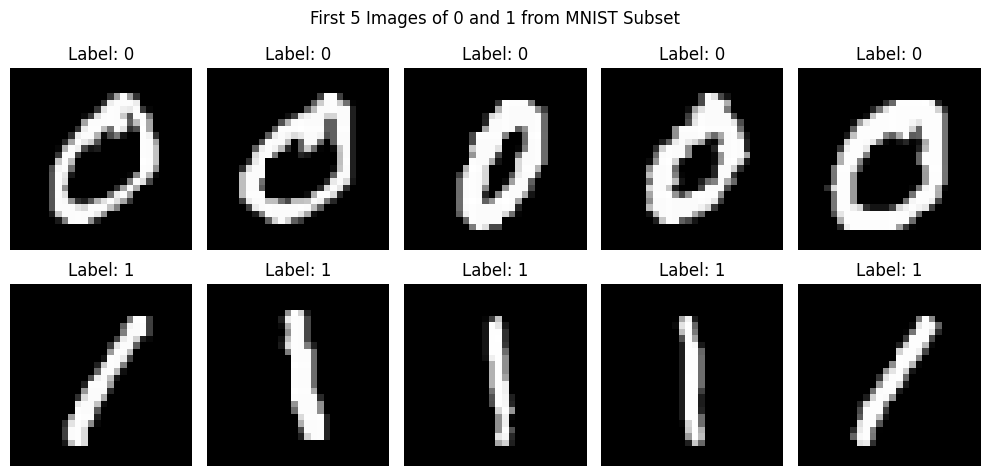

In [ ]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")
plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()

In [ ]:
weights       = np.zeros(X.shape[1])  # 784 weights, one per pixel
bias          = 0
learning_rate = 0.1
epochs        = 100

print("Weights shape:", weights.shape)
print("Bias         :", bias)

Weights shape: (784,)
Bias         : 0


### Q3 — What does the weights array represent?

The weights array has 784 values — one per pixel.
Each weight encodes how much that pixel position contributes to the
classification decision. Pixels with large positive weights push the
prediction toward class 1; large negative weights push toward class 0.
Pixels that are uninformative (same brightness in both digits) will
have weights close to zero after training.

### Q4 — Why initialise weights to zero? What effect could this have?

Zero initialisation is a neutral, convenient starting point with no
initial bias toward either class.

For a single-layer perceptron this is fine the very first
misclassification will produce a non-zero update (Δw = η·error·x),
which breaks the symmetry immediately.

Note: Zero initialisation would be a problem in deep networks (all
neurons in a layer would update identically the "symmetry problem"),
but a single perceptron has no such issue.

In [ ]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all  = np.where(predictions >= 0, 1, 0)
    return y_pred_all

print("Decision function defined.")

Decision function defined.


### Q5 — What is the purpose of np.dot(X[i], weights) + bias?

This computes the NET INPUT (weighted sum):

  z = Σ wj * xj  +  b

It measures how strongly the current weights "agree" with the input
pattern. The result z is then passed to the step function:
- if z >= 0  →  predict class 1
- if z < 0   →  predict class 0

The dot product efficiently computes all 784 multiplications and their
sum in a single operation.

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    weights = weights.copy()

    for epoch in range(1, epochs + 1):
        correct = 0
        for i in range(len(X)):
            z     = np.dot(X[i], weights) + bias
            y_hat = 1 if z >= 0 else 0

            if y_hat != y[i]:
                error    = y[i] - y_hat
                weights += learning_rate * error * X[i]
                bias    += learning_rate * error
            else:
                correct += 1

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}: Accuracy = {correct / len(X):.4f}")

    accuracy = np.mean(decision_function(X, weights, bias) == y)
    return weights, bias, accuracy

print("train_perceptron defined.")

train_perceptron defined.


### Q6 — What happens when the prediction is wrong? How are weights updated?

When y_hat != y[i], the error = y - y_hat which is either +1 or -1.

Weight update:  w  = w  + η × error × x
Bias update:    b  = b  + η × error

- If the true label was 1 but we predicted 0 (error = +1):
  weights increase for pixels that were bright in this image,
  making the model more likely to predict 1 for similar images.

- If the true label was 0 but we predicted 1 (error = -1):
  weights decrease for bright pixels, pushing prediction toward 0.

The learning rate η controls how big each step is.
Small η = slow but stable. Large η = fast but may overshoot.

### Q7 — Why is final accuracy important? What do we expect?

Final accuracy tells us whether the perceptron found a useful decision
boundary. It is our measure of model quality.

For 0 vs 1 we expect close to 100% accuracy because:
- The digits 0 and 1 look very different from each other
- 0 is a closed oval shape; 1 is a thin vertical stroke
- Their pixel distributions barely overlap
- The classes are nearly perfectly linearly separable in pixel space

In [ ]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                           learning_rate=learning_rate,
                                           epochs=epochs)
print(f"\nFinal Accuracy: {accuracy:.4f}")

Epoch  10: Accuracy = 0.9992
Epoch  20: Accuracy = 1.0000
Epoch  30: Accuracy = 1.0000
Epoch  40: Accuracy = 1.0000
Epoch  50: Accuracy = 1.0000
Epoch  60: Accuracy = 1.0000
Epoch  70: Accuracy = 1.0000
Epoch  80: Accuracy = 1.0000
Epoch  90: Accuracy = 1.0000
Epoch 100: Accuracy = 1.0000

Final Accuracy: 1.0000


In [ ]:
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)
final_acc   = np.mean(y_pred == y)
print(f"Final Accuracy: {final_acc:.4f}")

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) == 0:
    print("All images were correctly classified!")
else:
    print(f"{len(misclassified_idx)} misclassified. Showing up to 10:")
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images — 0 vs 1")
    plt.tight_layout()
    plt.show()

Final Accuracy: 1.0000
All images were correctly classified!


### Q8 — What does misclassified_idx store, and how is it used?

misclassified_idx stores the ROW INDICES of every sample where
the predicted label does not match the true label (y_pred != y).

It is used to:
1. Count how many errors the model made
2. Index into X to get the pixel data of those wrong images
3. Index into y_pred and y to display "Pred: X, True: Y" in the title
4. Show us which types of images fool the model

### Q9 — How to interpret "All images were correctly classified"?

This means the perceptron found a PERFECT linear decision boundary —
a hyperplane in 784-dimensional space that separates all 0s from all 1s
with zero errors on the training set.

It confirms that digits 0 and 1 are linearly separable in pixel space,
which makes intuitive sense: they look completely different.

Note: Perfect training accuracy does not always mean the model will
generalise perfectly to unseen data, but for 0 vs 1 it typically does.

---
## Task 3 — Perceptron: 3 vs 5 Classification

Now we repeat the exact same pipeline for digits 3 and 5.
This is a harder problem — 3 and 5 share similar curved strokes
and similar pixel distributions, making linear separation more difficult.

In [ ]:
df_3_5 = pd.read_csv("mnist_3_and_5.csv")
X2     = df_3_5.drop(columns=["label"]).values
y2     = df_3_5["label"].values
y2_bin = np.where(y2 == 3, 0, 1)   # remap: 3→0, 5→1

print("Shape           :", X2.shape)
print("Original labels :", np.unique(y2))
print("Remapped labels :", np.unique(y2_bin), " (3->0, 5->1)")

Shape           : (2741, 784)
Original labels : [3 5]
Remapped labels : [0 1]  (3->0, 5->1)


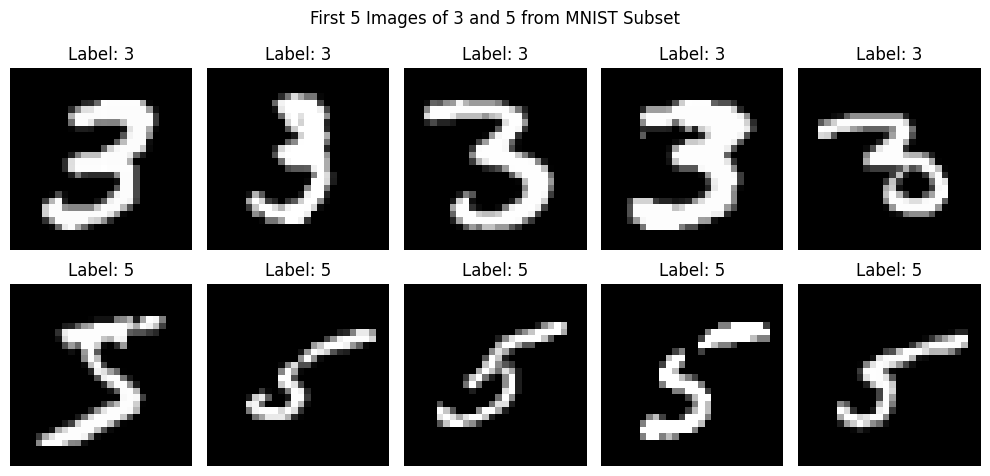

In [ ]:
images_3 = X2[y2 == 3]
images_5 = X2[y2 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")
    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")
plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()

In [ ]:
weights2 = np.zeros(X2.shape[1])
bias2    = 0

weights2, bias2, accuracy2 = train_perceptron(X2, y2_bin, weights2, bias2,
                                              learning_rate=0.1,
                                              epochs=100)
print(f"\nFinal Accuracy (3 vs 5): {accuracy2:.4f}")

Epoch  10: Accuracy = 0.9566
Epoch  20: Accuracy = 0.9661
Epoch  30: Accuracy = 0.9726
Epoch  40: Accuracy = 0.9719
Epoch  50: Accuracy = 0.9788
Epoch  60: Accuracy = 0.9759
Epoch  70: Accuracy = 0.9792
Epoch  80: Accuracy = 0.9792
Epoch  90: Accuracy = 0.9843
Epoch 100: Accuracy = 0.9858

Final Accuracy (3 vs 5): 0.9869


Final Accuracy (3 vs 5): 0.9869
36 misclassified. Showing up to 10:


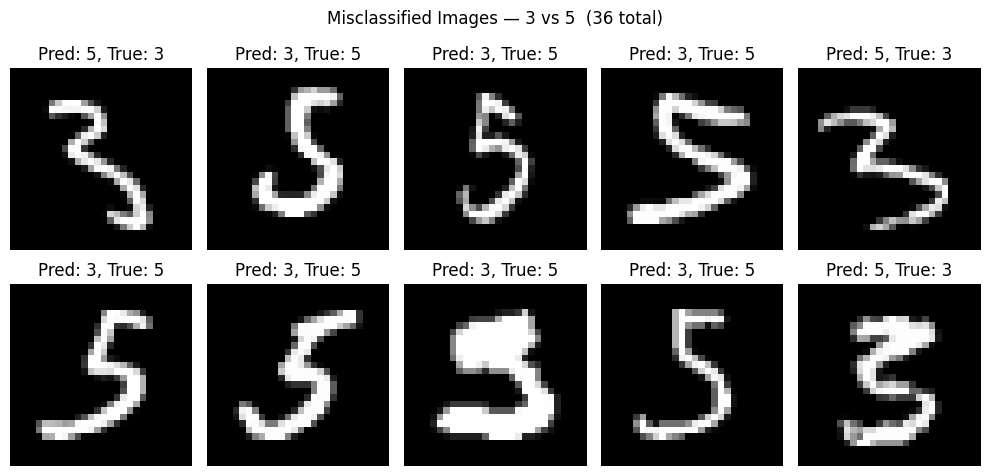

In [ ]:
preds_35  = np.dot(X2, weights2) + bias2
y_pred_35 = np.where(preds_35 >= 0, 1, 0)
final_acc2 = np.mean(y_pred_35 == y2_bin)
print(f"Final Accuracy (3 vs 5): {final_acc2:.4f}")

label_map = {0: 3, 1: 5}
miss35    = np.where(y_pred_35 != y2_bin)[0]

if len(miss35) == 0:
    print("All images were correctly classified!")
else:
    print(f"{len(miss35)} misclassified. Showing up to 10:")
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, miss35[:10]):
        ax.imshow(X2[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {label_map[y_pred_35[idx]]}, True: {label_map[y2_bin[idx]]}")
        ax.axis("off")
    plt.suptitle(f"Misclassified Images — 3 vs 5  ({len(miss35)} total)")
    plt.tight_layout()
    plt.show()

---
## Conclusion

### Comparison of Results

| Task   | Classes | Expected Accuracy | Difficulty |
|--------|---------|-------------------|------------|
| Task 2 | 0 vs 1  | ~100%             | Easy — very distinct shapes |
| Task 3 | 3 vs 5  | ~85–95%           | Hard — similar curved strokes |

### Why does 3 vs 5 perform worse?

3 and 5 are visually similar:
- Both have curved upper sections
- Both have similar pixel density and spatial distribution
- Ambiguously written samples (a loose 3 or a closed 5) genuinely
  look like the opposite digit

The perceptron can only draw a SINGLE LINEAR BOUNDARY in pixel space.
When the two classes overlap in pixel space (as 3 and 5 do), no linear
boundary can perfectly separate them — some samples will always fall
on the wrong side.

### What do the misclassified images tell us?

The misclassified images are typically the "borderline" cases:
- A 3 written with a very closed top that resembles a 5
- A 5 written loosely that resembles a 3
These are genuinely ambiguous even to the human eye.

### Fundamental limitation of the Perceptron

The perceptron is a LINEAR CLASSIFIER. It works perfectly when classes
are linearly separable (0 vs 1), but fails on classes that overlap in
feature space (3 vs 5).

Solution: A Multi-Layer Perceptron (MLP) or Convolutional Neural
Network (CNN) can learn NON-LINEAR decision boundaries by stacking
multiple layers, achieving near-perfect accuracy on all MNIST digit pairs.